In [17]:
%pip install pandas
%pip install matplotlib
import sqlite3
import pandas as pd
import numpy as np

# Connect to the database
DB_PATH = 'global.db'
conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Connected to global.db


## Database Schema
Let's first look at what tables exist and their structure.

In [18]:
# List all tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", 
    conn
)
print("Tables in database:")
display(tables)

Tables in database:


,name
0,combinations
1,material_embeddings
2,material_embeddings_chunks
3,material_embeddings_rowids
4,material_embeddings_vector_chunks00
5,materials
6,sqlite_sequence


In [19]:
# Show schema for combinations table
schema = pd.read_sql_query("PRAGMA table_info(combinations)", conn)
print("Combinations table schema:")
display(schema)

Combinations table schema:


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,firstWord,TEXT,1,None,0
2,2,secondWord,TEXT,1,None,0
3,3,resultName,TEXT,1,None,0
4,4,resultEmoji,TEXT,1,None,0
5,5,username,TEXT,1,None,0
6,6,timestamp,TIMESTAMP,1,None,0
7,7,perUserRank,INTEGER,0,None,0
8,8,isDiscovery,BOOLEAN,1,None,0


## Basic Statistics

In [20]:
# Overview stats
query = """
SELECT 
    COUNT(DISTINCT LOWER(resultName)) AS unique_words,
    COUNT(*) AS total_combinations
FROM combinations
"""
pd.read_sql_query(query, conn)

,unique_words,total_combinations
0,4844,12004


In [21]:
# Combinations per user
query = """
SELECT username, COUNT(*) AS combination_count
FROM combinations
GROUP BY username
ORDER BY combination_count DESC
"""
pd.read_sql_query(query, conn)

,username,combination_count
0,isabel,4916
1,tim,2179
2,ace,1378
3,izzy,1191
4,diana,541
5,Connor,444
6,vann,326
7,example,310
8,tiff,188
9,nicole,122


## Edge Statistics (Incoming/Outgoing)

## Throw Score Analysis

The "throw score" measures how much each input "throws" toward the result relative to the direction between inputs.

- **Between vector**: embedding from input1 → input2
- **Result vectors**: embeddings from input1 → result and input2 → result  
- **Throw score**: tuple of (cos_sim(result1, between), cos_sim(result2, between))

In [22]:
def get_embedding(word: str) -> np.ndarray:
    """Look up the embedding vector for a word from the materials table."""
    cursor = conn.cursor()
    cursor.execute('SELECT embedding FROM materials WHERE name = ?', (word,))
    result = cursor.fetchone()
    if result is None or result[0] is None:
        return None
    return np.frombuffer(result[0], dtype=np.float32)

def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    dot_product = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return float(dot_product / (norm1 * norm2))

def compute_throw_score(input1: str, input2: str, result: str) -> tuple[float, float] | None:
    """
    Compute the throw score for a combination.
    
    The throw score measures how aligned each input→result vector is 
    with the input1→input2 (between) vector.
    
    Args:
        input1: First input word
        input2: Second input word  
        result: Result word
        
    Returns:
        Tuple of (throw_score_1, throw_score_2) where:
        - throw_score_1 = cos_sim(input1→result, input1→input2)
        - throw_score_2 = cos_sim(input2→result, input1→input2)
        Returns None if any embedding is missing.
    """
    # Get embeddings from database
    emb_input1 = get_embedding(input1)
    emb_input2 = get_embedding(input2)
    emb_result = get_embedding(result)
    
    if emb_input1 is None or emb_input2 is None or emb_result is None:
        return None
    
    # Between vector: input1 → input2
    between_vec = emb_input2 - emb_input1
    
    # Result vectors: input1 → result and input2 → result
    result_vec_1 = emb_result - emb_input1
    result_vec_2 = emb_result - emb_input2
    
    # Compute throw scores (cosine similarities)
    throw_score_1 = abs(cosine_similarity(result_vec_1, between_vec))
    throw_score_2 = abs(cosine_similarity(result_vec_2, between_vec))
    
    return (throw_score_1, throw_score_2)

# Test with an example
example_score = compute_throw_score("Fire", "Water", "Steam")
if example_score:
    print(f"Throw score for Fire + Water = Steam: {example_score}")
    print(f"  Score 1 (Fire→Steam aligned with Fire→Water): {example_score[0]:.4f}")
    print(f"  Score 2 (Water→Steam aligned with Fire→Water): {example_score[1]:.4f}")
else:
    print("Could not compute throw score - missing embeddings")

Throw score for Fire + Water = Steam: (0.5307391881942749, 0.46215587854385376)
  Score 1 (Fire→Steam aligned with Fire→Water): 0.5307
  Score 2 (Water→Steam aligned with Fire→Water): 0.4622


In [23]:
# Compute throw scores for all combinations and analyze statistics
throw_scores = []
combinations_with_scores = []

# Use original case (not LOWER) since materials table has case-sensitive names
query = "SELECT firstWord, secondWord, resultName FROM combinations WHERE firstWord != secondWord"
combinations_df = pd.read_sql_query(query, conn)

for _, row in combinations_df.iterrows():
    score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
    if score:
        throw_score = max(score)  # Take the larger of the two scores
        throw_scores.append(throw_score)
        combinations_with_scores.append({
            'firstWord': row['firstWord'],
            'secondWord': row['secondWord'],
            'resultName': row['resultName'],
            'throw_score': throw_score
        })

print(f"Total combinations analyzed: {len(throw_scores)}")
print(f"\nThrow Score Statistics:")
print(f"  Smallest: {min(throw_scores):.4f}")
print(f"  Largest: {max(throw_scores):.4f}")
print(f"  Mean: {np.mean(throw_scores):.4f}")
print(f"  Median: {np.median(throw_scores):.4f}")

# Find combinations with min and max scores
scores_df = pd.DataFrame(combinations_with_scores)

# Min score combination
min_idx = scores_df['throw_score'].idxmin()
min_row = scores_df.loc[min_idx]
print(f"\nCombination with SMALLEST throw score:")
print(f"  {min_row['firstWord']} + {min_row['secondWord']} = {min_row['resultName']}")
print(f"  Score: {min_row['throw_score']:.4f}")

# Max score combination
max_idx = scores_df['throw_score'].idxmax()
max_row = scores_df.loc[max_idx]
print(f"\nCombination with LARGEST throw score:")
print(f"  {max_row['firstWord']} + {max_row['secondWord']} = {max_row['resultName']}")
print(f"  Score: {max_row['throw_score']:.4f}")

Total combinations analyzed: 7169

Throw Score Statistics:
  Smallest: 0.2466
  Largest: 1.0000
  Mean: 0.6203
  Median: 0.6070

Combination with SMALLEST throw score:
  Docker + Dock = Shipyard
  Score: 0.2466

Combination with LARGEST throw score:
  Legend + L = Legend
  Score: 1.0000


In [24]:
# Calculate average throw score per word (as either firstWord or secondWord)
word_scores = {}
word_examples = {}  # Store example combinations for each word

for combo in combinations_with_scores:
    for word in [combo['firstWord'], combo['secondWord']]:
        if word not in word_scores:
            word_scores[word] = []
            word_examples[word] = []
        word_scores[word].append(combo['throw_score'])
        word_examples[word].append({
            'combo': f"{combo['firstWord']} + {combo['secondWord']} = {combo['resultName']}",
            'score': combo['throw_score']
        })

# Compute averages and include examples
word_avg_scores = []
for word, scores in word_scores.items():
    # Get up to 3 examples, sorted by score
    examples = sorted(word_examples[word], key=lambda x: x['score'])
    example_strs = [f"{e['combo']} ({e['score']:.3f})" for e in examples[:3]]
    
    word_avg_scores.append({
        'word': word,
        'avg_throw_score': np.mean(scores),
        'num_combinations': len(scores),
        'examples': ' | '.join(example_strs)
    })

word_avg_df = pd.DataFrame(word_avg_scores).sort_values('avg_throw_score')

# Filter by minimum usage count
K = 5
word_avg_df_filtered = word_avg_df[word_avg_df['num_combinations'] >= K]

N = 20

print(f"Top {N} words with LOWEST average throw score (used at least {K} times):")
display(word_avg_df_filtered.head(N))

print(f"\nTop {N} words with HIGHEST average throw score (used at least {K} times):")
display(word_avg_df_filtered.tail(N).iloc[::-1])

Top 20 words with LOWEST average throw score (used at least 5 times):


,word,avg_throw_score,num_combinations,examples
1899,Pushover,0.516285,5,Cowardlypervert + Pushover = Doormat (0.474) |...
1768,Soulmate,0.518943,6,Soulmate + Soulmates = Love (0.249) | Soulmate...
393,Kagamiku,0.520294,6,Kagamiku + Yuri = Love (0.440) | Rinlen + Kaga...
914,Schizophrenia,0.529848,5,Schizophrenia + Psychosis = Madness (0.373) | ...
1071,Fury,0.530681,5,Avengers + Fury = Shield (0.435) | Fury + Rage...
526,Idol,0.536994,9,Kpop + Idol = Bts (0.491) | Idol + Hentai = Ec...
803,Femmefatale,0.537082,6,Dominatrix + Femmefatale = Seductress (0.412) ...
593,Summer,0.537184,10,Summer + Spring = Warmth (0.380) | Spring + Su...
1490,Pornstar,0.538531,5,Pussywhip + Pornstar = Bdsm (0.459) | Pussywhi...
1758,School,0.538556,8,Hentai + School = Ecchi (0.472) | School + Fis...



Top 20 words with HIGHEST average throw score (used at least 5 times):


,word,avg_throw_score,num_combinations,examples
253,Reboot,0.801408,6,Quadruplets + Reboot = Rebirth (0.590) | Reboo...
2350,Reactapp,0.783031,6,Revival + Reactapp = Reboot (0.594) | Reactapp...
1029,Liberation,0.765966,8,Galaxy + Liberation = Freedom Space (0.674) | ...
790,Neko,0.748497,23,Nekomimi + Neko = Catgirl (0.310) | Neko + Nek...
469,Fungus,0.742012,15,Pokemon + Fungus = Morelull (0.453) | Fungus +...
923,Disaster,0.738056,14,Harddrive + Disaster = Dataloss (0.535) | Disa...
466,Mold,0.737979,16,Mold + Scuba = Coral (0.601) | Fog + Mold = Mi...
1182,Wedding,0.737433,6,Wedding + Opensource = Openlove (0.635) | Wedd...
137,Wormhole,0.729727,5,Wormhole + Atlantis = Portal Ocean (0.553) | W...
2430,Health,0.729454,5,Health + Energy = Vitality (0.573) | Passion +...


In [25]:
# Word usage analysis
query = """
WITH word_usage AS (
  SELECT 
    word,
    SUM(used_as_input) AS incoming_edges,
    SUM(used_as_result) AS outgoing_edges
  FROM (
    SELECT LOWER(firstWord) AS word, 1 AS used_as_input, 0 AS used_as_result FROM combinations
    UNION ALL
    SELECT LOWER(secondWord) AS word, 1 AS used_as_input, 0 AS used_as_result FROM combinations
    UNION ALL
    SELECT LOWER(resultName) AS word, 0 AS used_as_input, 1 AS used_as_result FROM combinations
  )
  GROUP BY word
)
SELECT 
  ROUND(AVG(incoming_edges), 2) AS avg_incoming,
  ROUND(AVG(outgoing_edges), 2) AS avg_outgoing
FROM word_usage
"""
pd.read_sql_query(query, conn)

,avg_incoming,avg_outgoing
0,4.95,2.48


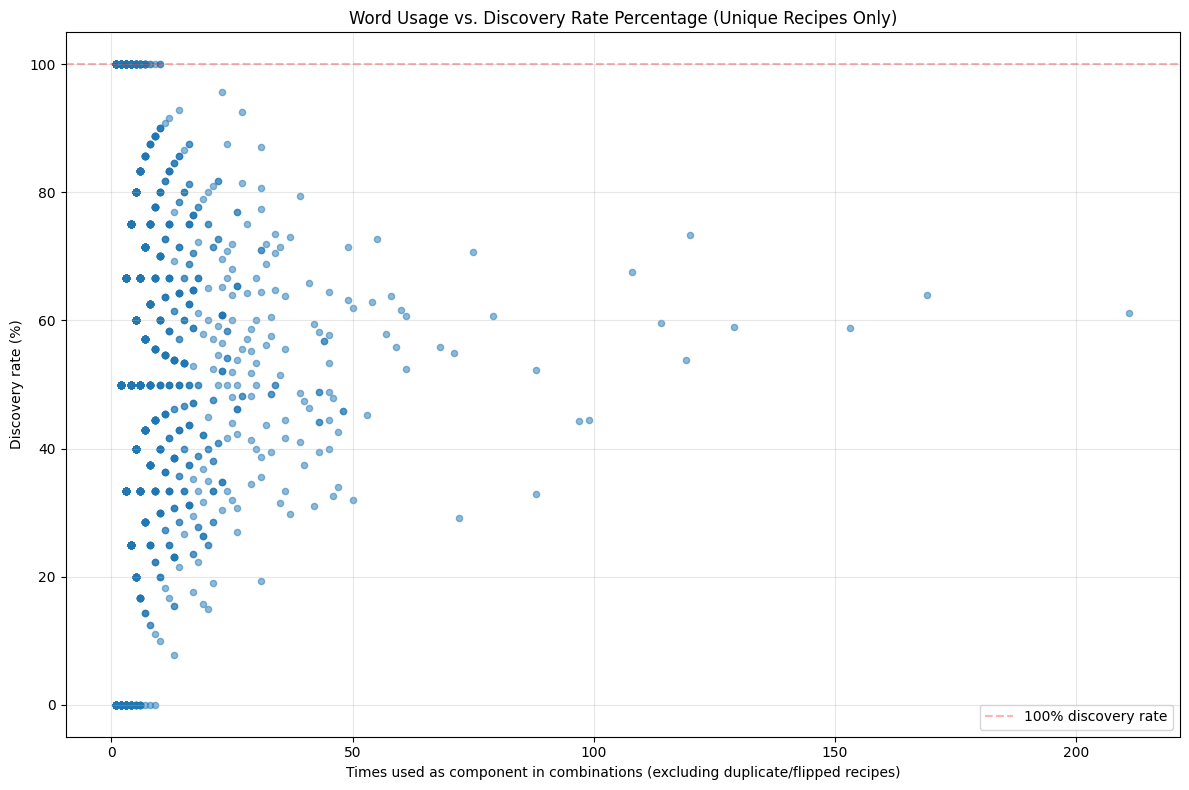

Total words analyzed: 4729
Total unique recipes: 10884
X range: 1 to 211
Y range: 0.00% to 100.00%


In [26]:
import matplotlib.pyplot as plt

# For each word, count:
# X = times used as component (firstWord or secondWord)
# Y = percentage of uses that resulted in new discovery for that user
# Skip duplicate/flipped recipes

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

word_stats = {}
seen_recipes_global = set()  # Track all normalized recipes we've seen

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

# Track what each user has discovered so far (by result name)
user_discovered = {}  # username -> set of result names they've seen

for _, row in combos.iterrows():
    username = row['username']
    result = row['resultName']
    
    # Get normalized recipe to detect flipped combinations
    normalized = normalize_recipe(row['firstWord'], row['secondWord'], result)
    
    # Skip if we've already seen this recipe (or its flip)
    if normalized in seen_recipes_global:
        continue
    seen_recipes_global.add(normalized)
    
    # Initialize user's discovery set if not exists
    if username not in user_discovered:
        user_discovered[username] = set()
    
    # Check if this result is new for this user
    is_discovery = result not in user_discovered[username]
    
    # Add result to user's discovered set
    user_discovered[username].add(result)
    
    # Track stats for both input words
    for word in [row['firstWord'], row['secondWord']]:
        if word not in word_stats:
            word_stats[word] = {'used': 0, 'discoveries': 0}
        
        word_stats[word]['used'] += 1
        
        # Count if this resulted in a new discovery for this user
        if is_discovery:
            word_stats[word]['discoveries'] += 1

# Create scatter plot data with percentages
x_vals = [stats['used'] for stats in word_stats.values()]
y_vals = [(stats['discoveries'] / stats['used'] * 100) if stats['used'] > 0 else 0 
          for stats in word_stats.values()]
words = list(word_stats.keys())

# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(x_vals, y_vals, alpha=0.5, s=20)
plt.xlabel('Times used as component in combinations (excluding duplicate/flipped recipes)')
plt.ylabel('Discovery rate (%)')
plt.title('Word Usage vs. Discovery Rate Percentage (Unique Recipes Only)')
plt.grid(True, alpha=0.3)

# Add reference line at 100%
plt.axhline(y=100, color='r', linestyle='--', alpha=0.3, label='100% discovery rate')
plt.ylim(-5, 105)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total words analyzed: {len(word_stats)}")
print(f"Total unique recipes: {len(seen_recipes_global)}")
print(f"X range: {min(x_vals)} to {max(x_vals)}")
print(f"Y range: {min(y_vals):.2f}% to {max(y_vals):.2f}%")

Top 4 users: ['isabel', 'tim', 'ace', 'izzy']


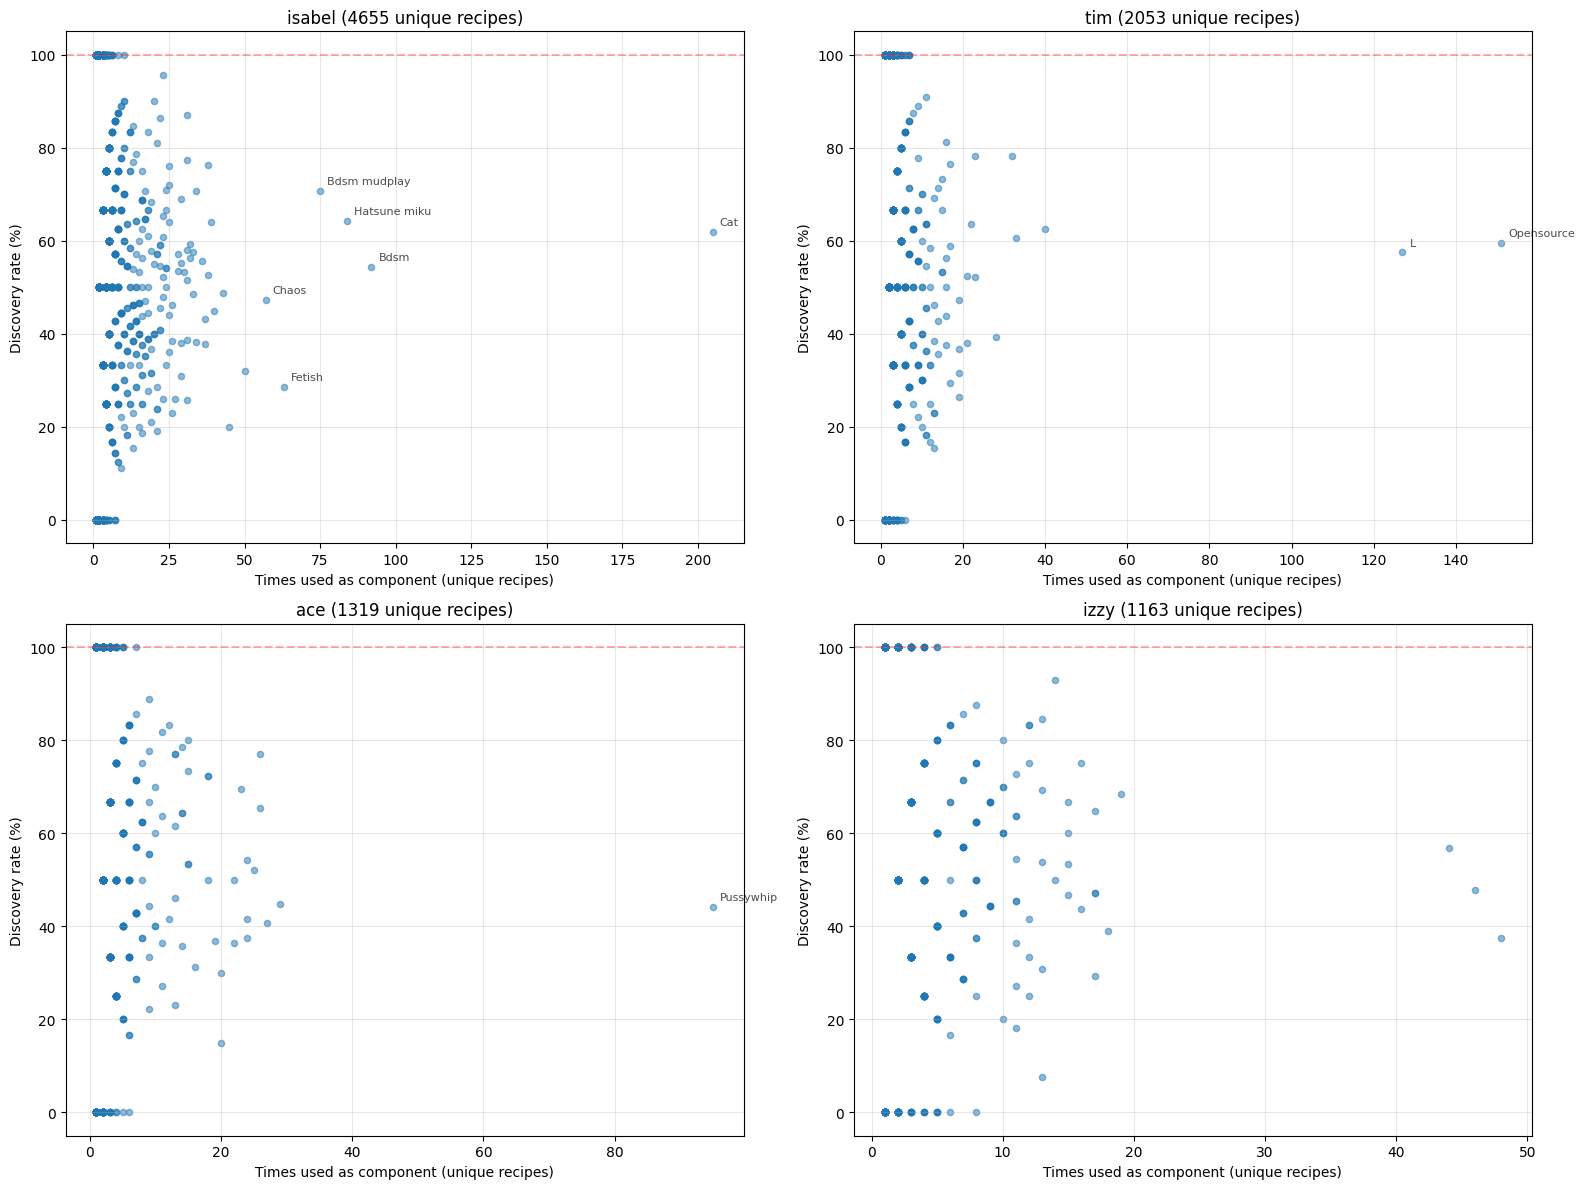


isabel: 4916 total combinations, 4655 unique recipes

tim: 2179 total combinations, 2053 unique recipes

ace: 1378 total combinations, 1319 unique recipes

izzy: 1191 total combinations, 1163 unique recipes


In [27]:
import matplotlib.pyplot as plt

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Get top 4 users by number of combinations
top_users_query = """
SELECT username, COUNT(*) as combo_count
FROM combinations
GROUP BY username
ORDER BY combo_count DESC
LIMIT 4
"""
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

print(f"Top 4 users: {top_users}")

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

# Create subplots for each user
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, username in enumerate(top_users):
    ax = axes[idx]
    
    # Filter combinations for this user
    user_combos = combos[combos['username'] == username]
    
    word_stats = {}
    user_discovered = set()  # Track what this user has discovered
    seen_recipes_user = set()  # Track normalized recipes for this user
    
    for _, row in user_combos.iterrows():
        result = row['resultName']
        
        # Get normalized recipe to detect flipped combinations
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], result)
        
        # Skip if we've already seen this recipe (or its flip) for this user
        if normalized in seen_recipes_user:
            continue
        seen_recipes_user.add(normalized)
        
        # Check if this result is new for this user
        is_discovery = result not in user_discovered
        
        # Add result to user's discovered set
        user_discovered.add(result)
        
        # Track stats for both input words
        for word in [row['firstWord'], row['secondWord']]:
            if row['firstWord'] == row['secondWord']:  # Skip same-component combos
                continue
                
            if word not in word_stats:
                word_stats[word] = {'used': 0, 'discoveries': 0}
            
            word_stats[word]['used'] += 1
            
            # Count if this resulted in a new discovery for this user
            if is_discovery:
                word_stats[word]['discoveries'] += 1
    
    # Create scatter plot data with percentages
    words = list(word_stats.keys())
    x_vals = [stats['used'] for stats in word_stats.values()]
    y_vals = [(stats['discoveries'] / stats['used'] * 100) if stats['used'] > 0 else 0 
              for stats in word_stats.values()]
    
    # Plot
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    
    # Label outlier words (used more than 50 times)
    for i, (word, x, y) in enumerate(zip(words, x_vals, y_vals)):
        if x > 50:
            ax.annotate(word, (x, y), fontsize=8, alpha=0.7, 
                       xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('Times used as component (unique recipes)')
    ax.set_ylabel('Discovery rate (%)')
    ax.set_title(f'{username} ({len(seen_recipes_user)} unique recipes)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.3)
    ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

# Print summary statistics for each user
for username in top_users:
    user_combos = combos[combos['username'] == username]
    seen_recipes_user = set()
    for _, row in user_combos.iterrows():
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
        seen_recipes_user.add(normalized)
    print(f"\n{username}: {len(user_combos)} total combinations, {len(seen_recipes_user)} unique recipes")

In [28]:
# Analyze all combinations for a specific word
WORD_TO_ANALYZE = "L"  # Change this to analyze different words

# Get ALL combinations ordered by id to properly track discoveries
all_combos = pd.read_sql_query("""
    SELECT id, firstWord, secondWord, resultName, username
    FROM combinations
    ORDER BY id
""", conn)

# Helper function to normalize recipe (canonical form: lower ingredient alphabetically)
def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Track what each user has discovered and how they discovered it
user_discovered_so_far = {}  # username -> {normalized_recipe: (discovery_combo, result)}
user_seen_recipes = {}  # username -> set of normalized recipes they've seen
results = []

for _, row in all_combos.iterrows():
    username = row['username']
    result = row['resultName']
    combo_str = f"{row['firstWord']} + {row['secondWord']} = {result}"
    
    # Initialize user tracking
    if username not in user_discovered_so_far:
        user_discovered_so_far[username] = {}
        user_seen_recipes[username] = set()
    
    # Get normalized recipe to detect flipped combos
    normalized = normalize_recipe(row['firstWord'], row['secondWord'], result)
    
    # Check if this combination uses our word
    uses_word = (row['firstWord'] == WORD_TO_ANALYZE or row['secondWord'] == WORD_TO_ANALYZE)
    
    # Only count if this user hasn't seen this exact recipe (or its flip) before
    if uses_word and normalized not in user_seen_recipes[username]:
        # Check if this result was already discovered by this user via any recipe
        was_discovery = result not in user_discovered_so_far[username]
        
        discovery_combo = None
        if not was_discovery:
            # Get the original discovery combination for this result
            discovery_combo = user_discovered_so_far[username][result]
        
        results.append({
            'id': row['id'],
            'combination': combo_str,
            'username': username,
            'was_discovery': '✓' if was_discovery else '✗',
            'discovery_combo': discovery_combo if discovery_combo else '-'
        })
    
    # Track this recipe and result for the user (for ALL combinations)
    user_seen_recipes[username].add(normalized)
    if result not in user_discovered_so_far[username]:
        user_discovered_so_far[username][result] = combo_str

if len(results) == 0:
    print(f"No combinations found for word: {WORD_TO_ANALYZE}")
else:
    print(f"Found {len(results)} combinations using '{WORD_TO_ANALYZE}' (excluding duplicate/flipped recipes)")
    print()
    
    # Display as DataFrame
    results_df = pd.DataFrame(results)
    display(results_df)
    
    # Summary statistics
    total_discoveries = len([r for r in results if r['was_discovery'] == '✓'])
    discovery_rate = (total_discoveries / len(results) * 100) if len(results) > 0 else 0
    
    print(f"\nSummary for '{WORD_TO_ANALYZE}':")
    print(f"  Total unique recipes: {len(results)}")
    print(f"  Discoveries: {total_discoveries}")
    print(f"  Discovery rate: {discovery_rate:.1f}%")

Found 128 combinations using 'L' (excluding duplicate/flipped recipes)



,id,combination,username,was_discovery,discovery_combo
0,4509,L + L = Llama,tim,✓,-
1,4511,Tapestry + L = Landscape,tim,✓,-
2,4512,Fury + L = Hurricane,tim,✗,Storm + Ocean = Hurricane
3,4513,L + Opera whip = Lasso,tim,✓,-
4,4514,L + Bohemian rhapsody = Queen,tim,✓,-
...,...,...,...,...,...
123,8208,Opencontainer + L = Bottle,tim,✓,-
124,9264,L + Nostalgia = Longing,tim,✓,-
125,9475,Nothing + L = Void,tim,✗,Oblivion + Oblivion = Void
126,9591,Learning + L = Literacy,tim,✓,-



Summary for 'L':
  Total unique recipes: 128
  Discoveries: 74
  Discovery rate: 57.8%


Top 4 users: ['isabel', 'tim', 'ace', 'izzy']


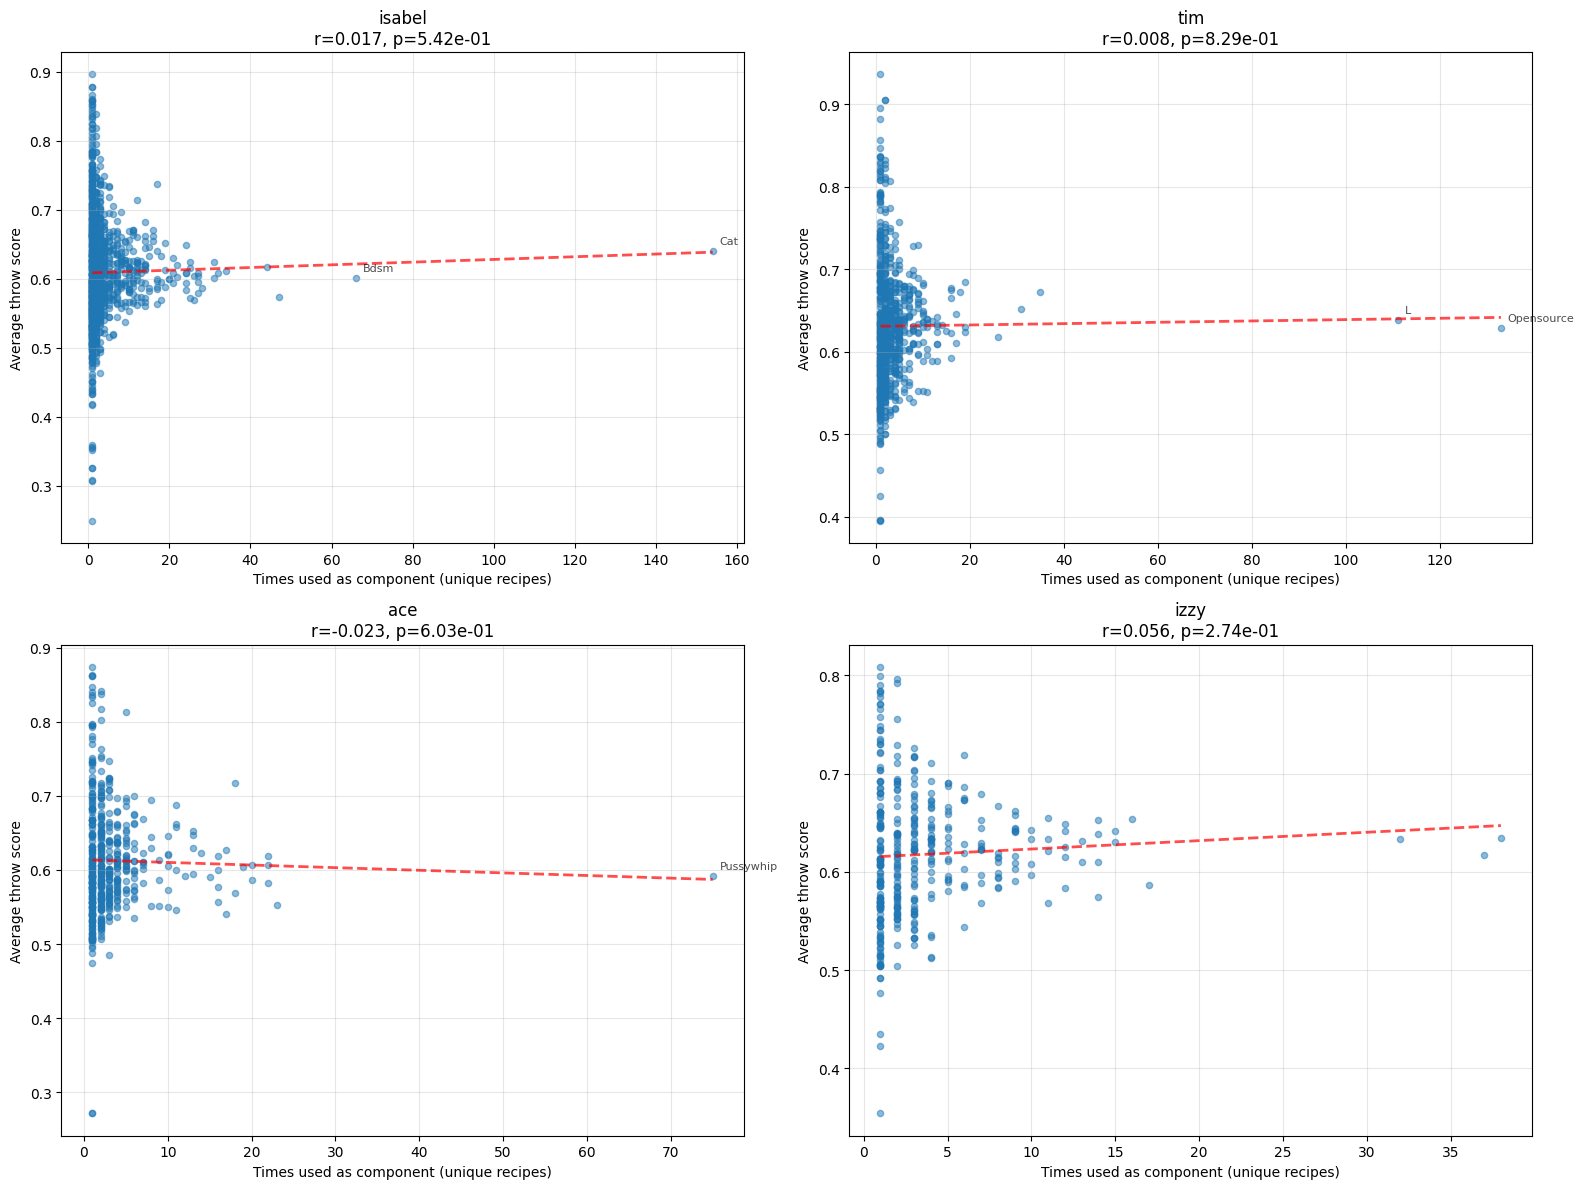


isabel: 4707 total combinations, 4476 unique recipes

tim: 1930 total combinations, 1831 unique recipes

ace: 1307 total combinations, 1255 unique recipes

izzy: 1114 total combinations, 1090 unique recipes


In [29]:
import matplotlib.pyplot as plt
from scipy import stats

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Get top 4 users by number of combinations
top_users_query = """
SELECT username, COUNT(*) as combo_count
FROM combinations
GROUP BY username
ORDER BY combo_count DESC
LIMIT 4
"""
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

print(f"Top 4 users: {top_users}")

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
WHERE firstWord != secondWord
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

# Create subplots for each user
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, username in enumerate(top_users):
    ax = axes[idx]
    
    # Filter combinations for this user
    user_combos = combos[combos['username'] == username]
    
    word_usage_count = {}  # word -> count of unique recipes
    word_throw_scores = {}  # word -> list of throw scores
    seen_recipes_user = set()  # Track normalized recipes for this user
    
    for _, row in user_combos.iterrows():
        # Get normalized recipe to detect flipped combinations
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
        
        # Skip if we've already seen this recipe (or its flip) for this user
        if normalized in seen_recipes_user:
            continue
        seen_recipes_user.add(normalized)
        
        # Compute throw score for this combination
        score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
        if score is None:
            continue
        
        throw_score = max(score)
        
        # Track stats for both input words
        for word in [row['firstWord'], row['secondWord']]:
            if word not in word_usage_count:
                word_usage_count[word] = 0
                word_throw_scores[word] = []
            
            word_usage_count[word] += 1
            word_throw_scores[word].append(throw_score)
    
    # Create scatter plot data
    words = []
    x_vals = []  # usage count
    y_vals = []  # average throw score
    
    for word in word_usage_count.keys():
        if len(word_throw_scores[word]) > 0:
            words.append(word)
            x_vals.append(word_usage_count[word])
            y_vals.append(np.mean(word_throw_scores[word]))
    
    if len(x_vals) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{username} (insufficient data)')
        continue
    
    # Convert to numpy arrays for statistics
    x_array = np.array(x_vals)
    y_array = np.array(y_vals)
    
    # Calculate line of best fit
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_array, y_array)
    line_x = np.array([min(x_vals), max(x_vals)])
    line_y = slope * line_x + intercept
    
    # Plot
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    ax.plot(line_x, line_y, 'r--', linewidth=2, alpha=0.7)
    
    # Label outlier words (used more than 50 times)
    for i, (word, x, y) in enumerate(zip(words, x_vals, y_vals)):
        if x > 50:
            ax.annotate(word, (x, y), fontsize=8, alpha=0.7, 
                       xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('Times used as component (unique recipes)')
    ax.set_ylabel('Average throw score')
    ax.set_title(f'{username}\nr={r_value:.3f}, p={p_value:.2e}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for each user
for i, username in enumerate(top_users):
    user_combos = combos[combos['username'] == username]
    seen_recipes_user = set()
    for _, row in user_combos.iterrows():
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
        seen_recipes_user.add(normalized)
    
    print(f"\n{username}: {len(user_combos)} total combinations, {len(seen_recipes_user)} unique recipes")

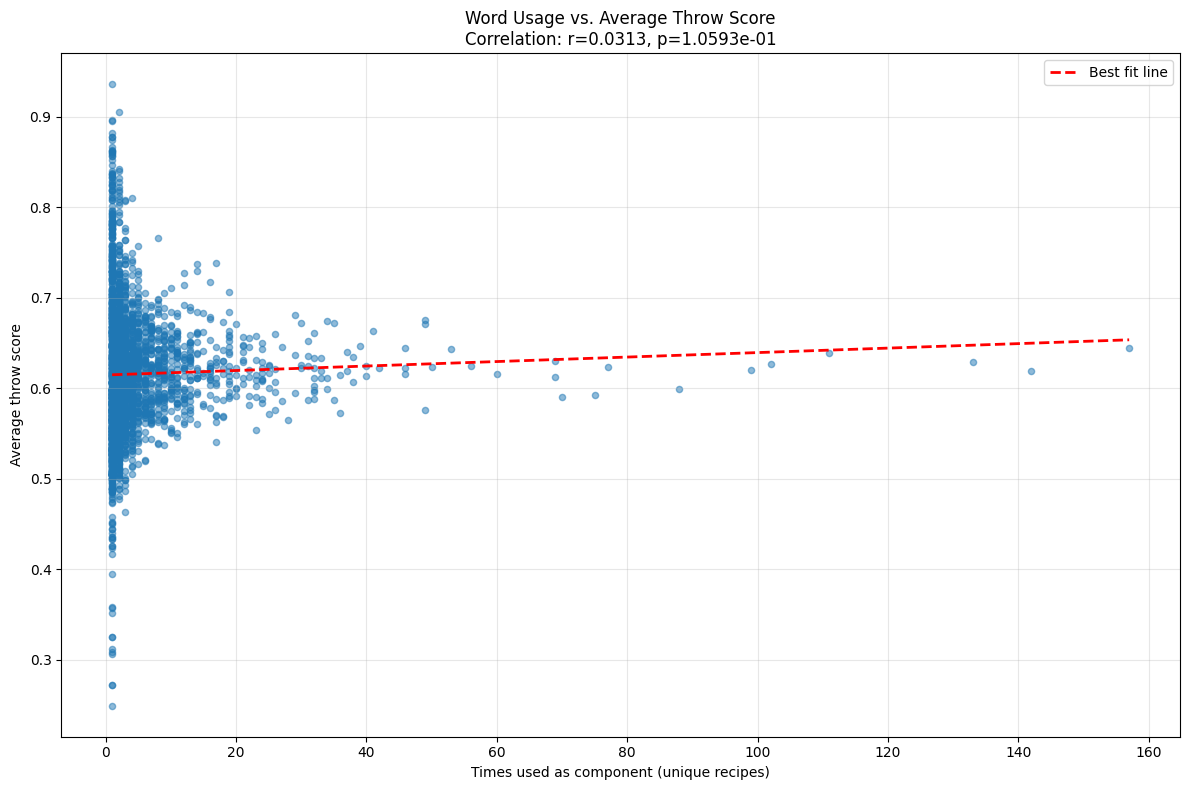

Total words analyzed: 2674
Total unique recipes: 10179
X range: 1 to 157
Y range: 0.2491 to 0.9358

Correlation coefficient (r): 0.0313
R-squared: 0.0010
P-value: 1.0593e-01
Slope: 0.000248
Intercept: 0.6145


In [30]:
import matplotlib.pyplot as plt
from scipy import stats

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Build word usage and throw score statistics (excluding flipped recipes)
word_usage_count = {}  # word -> count of unique recipes
word_throw_scores = {}  # word -> list of throw scores
seen_recipes_global = set()

# Get all combinations with throw scores
query = """
SELECT firstWord, secondWord, resultName 
FROM combinations 
WHERE firstWord != secondWord
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

for _, row in combos.iterrows():
    # Get normalized recipe to detect flipped combinations
    normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])
    
    # Skip if we've already seen this recipe (or its flip)
    if normalized in seen_recipes_global:
        continue
    seen_recipes_global.add(normalized)
    
    # Compute throw score for this combination
    score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
    if score is None:
        continue
    
    throw_score = max(score)  # Take the larger of the two scores
    
    # Track stats for both input words
    for word in [row['firstWord'], row['secondWord']]:
        if word not in word_usage_count:
            word_usage_count[word] = 0
            word_throw_scores[word] = []
        
        word_usage_count[word] += 1
        word_throw_scores[word].append(throw_score)

# Create scatter plot data
words = []
x_vals = []  # usage count
y_vals = []  # average throw score

for word in word_usage_count.keys():
    if len(word_throw_scores[word]) > 0:
        words.append(word)
        x_vals.append(word_usage_count[word])
        y_vals.append(np.mean(word_throw_scores[word]))

# Convert to numpy arrays for statistics
x_array = np.array(x_vals)
y_array = np.array(y_vals)

# Calculate line of best fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x_array, y_array)
line_x = np.array([min(x_vals), max(x_vals)])
line_y = slope * line_x + intercept

# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(x_vals, y_vals, alpha=0.5, s=20)
plt.plot(line_x, line_y, 'r--', linewidth=2, label=f'Best fit line')
plt.xlabel('Times used as component (unique recipes)')
plt.ylabel('Average throw score')
plt.title(f'Word Usage vs. Average Throw Score\nCorrelation: r={r_value:.4f}, p={p_value:.4e}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total words analyzed: {len(words)}")
print(f"Total unique recipes: {len(seen_recipes_global)}")
print(f"X range: {min(x_vals)} to {max(x_vals)}")
print(f"Y range: {min(y_vals):.4f} to {max(y_vals):.4f}")
print(f"\nCorrelation coefficient (r): {r_value:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.4f}")

Top 4 users: ['isabel', 'tim', 'ace', 'izzy']


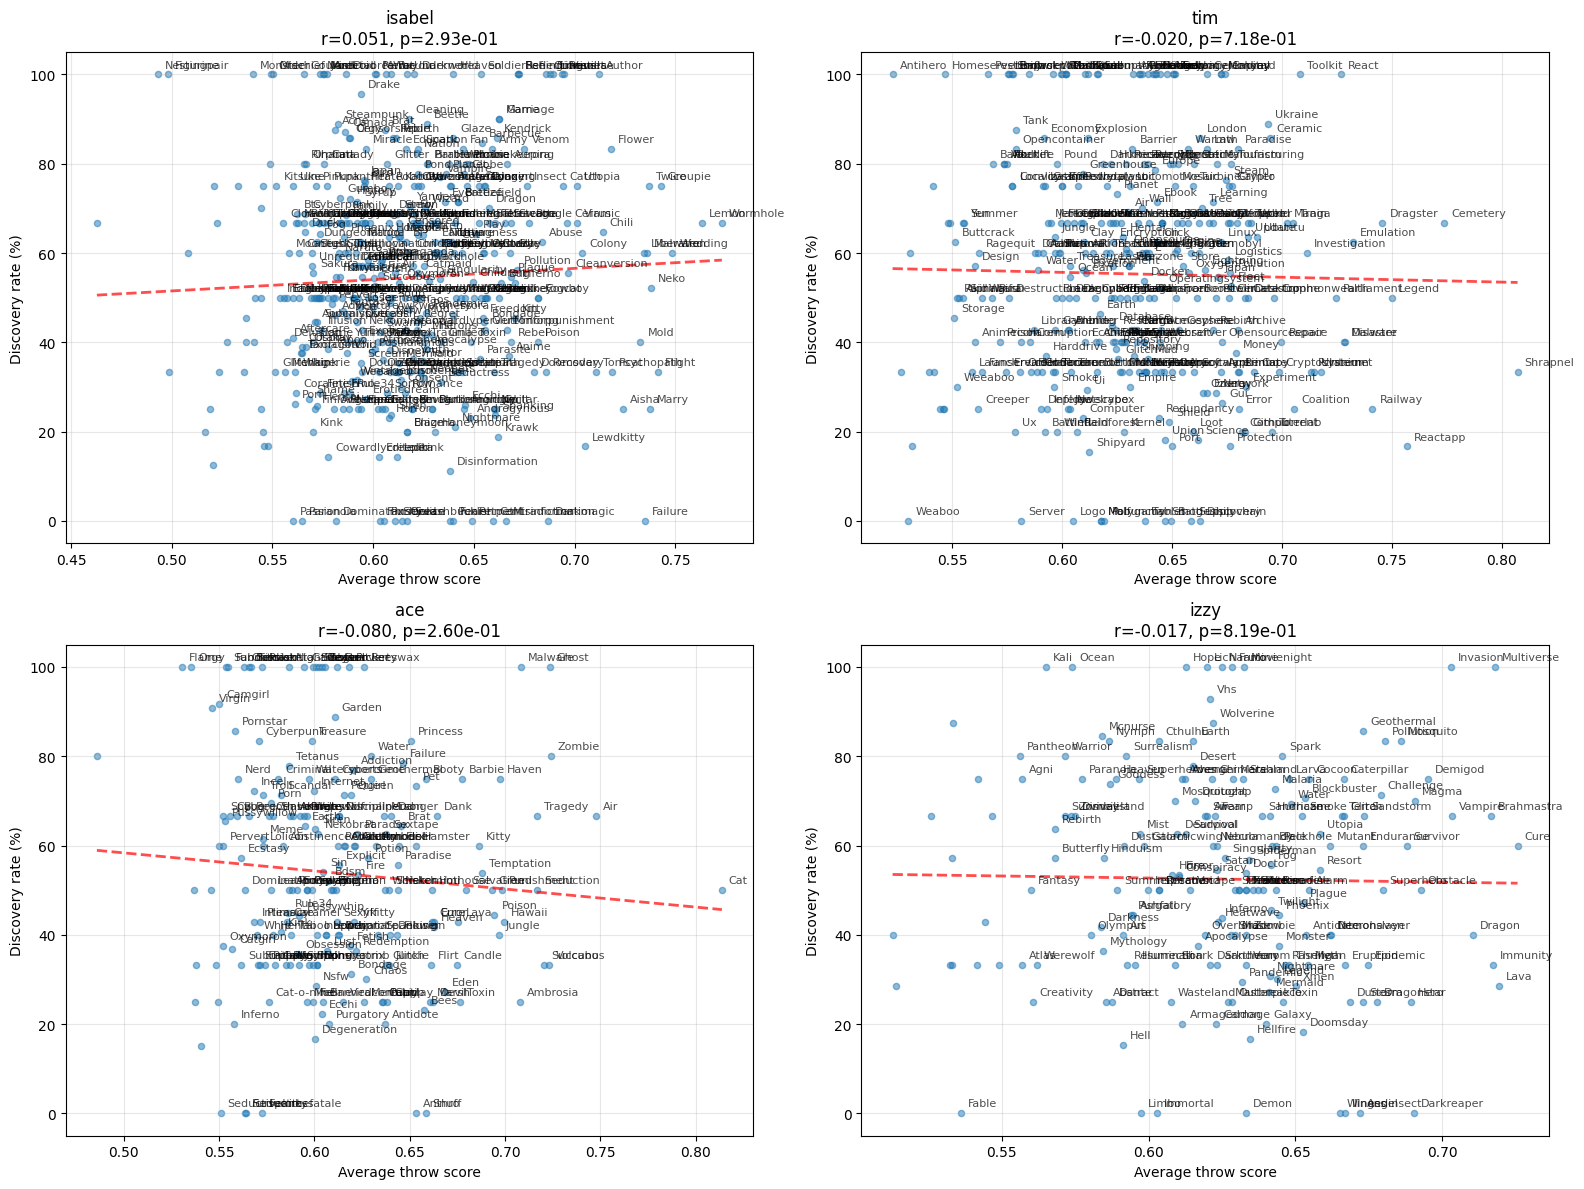


isabel: 4707 total combinations, 0 unique recipes

isabel: 4707 total combinations, 1 unique recipes

isabel: 4707 total combinations, 2 unique recipes

isabel: 4707 total combinations, 3 unique recipes

isabel: 4707 total combinations, 3 unique recipes

isabel: 4707 total combinations, 4 unique recipes

isabel: 4707 total combinations, 5 unique recipes

isabel: 4707 total combinations, 6 unique recipes

isabel: 4707 total combinations, 7 unique recipes

isabel: 4707 total combinations, 8 unique recipes

isabel: 4707 total combinations, 9 unique recipes

isabel: 4707 total combinations, 10 unique recipes

isabel: 4707 total combinations, 10 unique recipes

isabel: 4707 total combinations, 11 unique recipes

isabel: 4707 total combinations, 12 unique recipes

isabel: 4707 total combinations, 13 unique recipes

isabel: 4707 total combinations, 14 unique recipes

isabel: 4707 total combinations, 15 unique recipes

isabel: 4707 total combinations, 16 unique recipes

isabel: 4707 total com

In [31]:
import matplotlib.pyplot as plt
from scipy import stats

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Get top 4 users by number of combinations
top_users_query = """
SELECT username, COUNT(*) as combo_count
FROM combinations
GROUP BY username
ORDER BY combo_count DESC
LIMIT 4
"""
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

print(f"Top 4 users: {top_users}")

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
WHERE firstWord != secondWord
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

# Create subplots for each user
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, username in enumerate(top_users):
    ax = axes[idx]
    
    # Filter combinations for this user
    user_combos = combos[combos['username'] == username]
    
    word_throw_scores = {}  # word -> list of throw scores
    word_discovery_stats = {}  # word -> {'used': count, 'discoveries': count}
    user_discovered = set()  # Track what this user has discovered
    seen_recipes_user = set()  # Track normalized recipes for this user
    
    for _, row in user_combos.iterrows():
        result = row['resultName']
        
        # Get normalized recipe to detect flipped combinations
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], result)
        
        # Skip if we've already seen this recipe (or its flip) for this user
        if normalized in seen_recipes_user:
            continue
        seen_recipes_user.add(normalized)
        
        # Check if this result is new for this user
        is_discovery = result not in user_discovered
        
        # Add result to user's discovered set
        user_discovered.add(result)
        
        # Compute throw score for this combination
        score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
        
        # Track stats for both input words
        for word in [row['firstWord'], row['secondWord']]:
            # Track throw scores
            if score is not None:
                if word not in word_throw_scores:
                    word_throw_scores[word] = []
                word_throw_scores[word].append(max(score))
            
            # Track discovery stats
            if word not in word_discovery_stats:
                word_discovery_stats[word] = {'used': 0, 'discoveries': 0}
            
            word_discovery_stats[word]['used'] += 1
            
            # Count if this resulted in a new discovery for this user
            if is_discovery:
                word_discovery_stats[word]['discoveries'] += 1
    
    # Minimum usage threshold
    K = 3
    
    # Create scatter plot data
    words = []
    x_vals = []  # average throw score
    y_vals = []  # discovery rate percentage
    
    for word in word_discovery_stats.keys():
        # Only include words that have both throw scores and discovery data
        # AND were used at least K times
        if (word in word_throw_scores and 
            len(word_throw_scores[word]) >= K):
            avg_throw = np.mean(word_throw_scores[word])
            discovery_rate = (word_discovery_stats[word]['discoveries'] / 
                             word_discovery_stats[word]['used'] * 100)
            
            words.append(word)
            x_vals.append(avg_throw)
            y_vals.append(discovery_rate)
    
    if len(x_vals) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{username} (insufficient data)')
        continue
    
    # Convert to numpy arrays for statistics
    x_array = np.array(x_vals)
    y_array = np.array(y_vals)
    
    # Calculate line of best fit
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_array, y_array)
    line_x = np.array([min(x_vals), max(x_vals)])
    line_y = slope * line_x + intercept
    
    # Plot
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    ax.plot(line_x, line_y, 'r--', linewidth=2, alpha=0.7)
    
    # Label outlier words (high throw score or extreme discovery rate)
    for i, (word, x, y) in enumerate(zip(words, x_vals, y_vals)):
        # Label if throw score > 0.55 or discovery rate > 90% or < 10%
        if x > 0.55 or y > 90 or y < 10:
            ax.annotate(word, (x, y), fontsize=8, alpha=0.7, 
                       xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('Average throw score')
    ax.set_ylabel('Discovery rate (%)')
    ax.set_title(f'{username}\nr={r_value:.3f}, p={p_value:.2e}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

# Print summary statistics for each user
for i, username in enumerate(top_users):
    user_combos = combos[combos['username'] == username]
    seen_recipes_user = set()

    for _, row in user_combos.iterrows():    
        print(f"\n{username}: {len(user_combos)} total combinations, {len(seen_recipes_user)} unique recipes")
        normalized = normalize_recipe(row['firstWord'], row['secondWord'], row['resultName'])    
        seen_recipes_user.add(normalized)

In [32]:
import matplotlib.pyplot as plt
from scipy import stats

def normalize_recipe(word1, word2, result):
    """Return a normalized recipe key to detect flipped combinations"""
    ingredients = tuple(sorted([word1, word2]))
    return (ingredients, result)

# Build both throw score stats and discovery stats
word_throw_scores = {}  # word -> list of throw scores
word_discovery_stats = {}  # word -> {'used': count, 'discoveries': count}
seen_recipes_global = set()

# Get all combinations ordered by id
query = """
SELECT 
    id,
    firstWord, 
    secondWord, 
    resultName, 
    username
FROM combinations
WHERE firstWord != secondWord
ORDER BY id
"""
combos = pd.read_sql_query(query, conn)

# Track what each user has discovered so far (by result name)
user_discovered = {}  # username -> set of result names they've seen

for _, row in combos.iterrows():
    username = row['username']
    result = row['resultName']
    
    # Get normalized recipe to detect flipped combinations
    normalized = normalize_recipe(row['firstWord'], row['secondWord'], result)
    
    # Skip if we've already seen this recipe (or its flip)
    if normalized in seen_recipes_global:
        continue
    seen_recipes_global.add(normalized)
    
    # Initialize user's discovery set if not exists
    if username not in user_discovered:
        user_discovered[username] = set()
    
    # Check if this result is new for this user
    is_discovery = result not in user_discovered[username]
    
    # Add result to user's discovered set
    user_discovered[username].add(result)
    
    # Compute throw score for this combination
    score = compute_throw_score(row['firstWord'], row['secondWord'], row['resultName'])
    
    # Track stats for both input words
    for word in [row['firstWord'], row['secondWord']]:
        # Track throw scores
        if score is not None:
            if word not in word_throw_scores:
                word_throw_scores[word] = []
            word_throw_scores[word].append(max(score))
        
        # Track discovery stats
        if word not in word_discovery_stats:
            word_discovery_stats[word] = {'used': 0, 'discoveries': 0}
        
        word_discovery_stats[word]['used'] += 1
        
        # Count if this resulted in a new discovery for this user
        if is_discovery:
            word_discovery_stats[word]['discoveries'] += 1

# Minimum usage threshold
K = 3

# Create scatter plot data
words = []
x_vals = []  # average throw score
y_vals = []  # discovery rate percentage

for word in word_discovery_stats.keys():
    # Only include words that have both throw scores and discovery data
    # AND were used at least K times
    if (word in word_throw_scores and 
        len(word_throw_scores[word]) >= K):
        avg_throw = np.mean(word_throw_scores[word])
        discovery_rate = (word_discovery_stats[word]['discoveries'] / 
                         word_discovery_stats[word]['used'] * 100)
        
        words.append(word)
        x_vals.append(avg_throw)
        y_vals.append(discovery_rate)

# Convert to numpy arrays for statistics
x_array = np.array(x_vals)
y_array = np.array(y_vals)

# Calculate line of best fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x_array, y_array)
line_x = np.array([min(x_vals), max(x_vals)])
line_y = slope * line_x + intercept

# Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(x_vals, y_vals, alpha=0.5, s=20)
plt.plot(line_x, line_y, 'r--', linewidth=2, label=f'Best fit line')
plt.xlabel('Average throw score')
plt.ylabel('Discovery rate (%)')
plt.title(f'Average Throw Score vs. Discovery Rate (words used ≥{K} times)\nCorrelation: r={r_value:.4f}, p={p_value:.4e}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total words analyzed: {len(words)} (filtered to ≥{K} uses)")
print(f"Total unique recipes: {len(seen_recipes_global)}")
print(f"X range (avg throw score): {min(x_vals):.4f} to {max(x_vals):.4f}")
print(f"Y range (discovery %): {min(y_vals):.2f}% to {max(y_vals):.2f}%")

print(f"\nCorrelation coefficient (r): {r_value:.4f}")print(f"Intercept: {intercept:.4f}")

print(f"R-squared: {r_value**2:.4f}")print(f"Slope: {slope:.4f}")
print(f"P-value: {p_value:.4e}")

SyntaxError: invalid syntax (4244666143.py, line 122)

## Word Usage vs. Average Throw Score

Analyze the relationship between how often a word is used and its average throw score.

In [ ]:
# Top words by incoming edges (most used as inputs)
query = """
WITH word_usage AS (
  SELECT 
    word,
    SUM(used_as_input) AS incoming_edges
  FROM (
    SELECT LOWER(firstWord) AS word, 1 AS used_as_input FROM combinations
    UNION ALL
    SELECT LOWER(secondWord) AS word, 1 AS used_as_input FROM combinations
  )
  GROUP BY word
)
SELECT word, incoming_edges
FROM word_usage
ORDER BY incoming_edges DESC
LIMIT 20
"""
pd.read_sql_query(query, conn)

,word,incoming_edges
0,cat,237
1,earth,223
2,fire,157
3,opensource,156
4,l,155
5,water,144
6,bdsm,139
7,air,135
8,pussywhip,116
9,hatsune miku,115


In [ ]:
# Compute betweenness centrality per user
print("Computing betweenness centrality for top 4 users...\n")

top_users_query = """
SELECT username, COUNT(*) as combo_count
FROM combinations
GROUP BY username
ORDER BY combo_count DESC
LIMIT 4
"""
top_users = pd.read_sql_query(top_users_query, conn)['username'].tolist()

user_betweenness_dfs = {}

for username in top_users:
    print(f"\n{'='*60}")
    print(f"USER: {username}")
    print('='*60)
    
    user_df = compute_all_betweenness_centrality(username=username)
    user_betweenness_dfs[username] = user_df
    
    print(f"\nTop 15 words by betweenness centrality for {username}:")
    display(user_df.head(15))

Computing betweenness centrality for top 4 users...


USER: isabel
Computing betweenness centrality for 3458 nodes (directed graph)...
  Processing node 3400/3458...
Done! Computed betweenness for 3458 nodes.

Top 15 words by betweenness centrality for isabel:
  Processing node 3400/3458...
Done! Computed betweenness for 3458 nodes.

Top 15 words by betweenness centrality for isabel:


,word,betweenness_centrality,out_degree,in_degree
885,Bdsm,0.062111,71,59
35,Chaos,0.037170,44,40
1450,Cat,0.032980,158,8
880,Fetish,0.032263,34,29
1455,Kitten,0.029629,33,31
228,Moe,0.029096,29,30
884,Kink,0.023639,24,41
970,Bondage,0.022912,16,28
635,Horror,0.018788,20,20
878,Ecchi,0.018375,18,35



USER: tim
Computing betweenness centrality for 1302 nodes (directed graph)...
  Processing node 1300/1302...
Done! Computed betweenness for 1302 nodes.

Top 15 words by betweenness centrality for tim:
  Processing node 1300/1302...
Done! Computed betweenness for 1302 nodes.

Top 15 words by betweenness centrality for tim:


,word,betweenness_centrality,out_degree,in_degree
728,Linux,0.136485,32,36
751,Opensource,0.073397,108,4
733,Ubuntu,0.068114,10,10
494,Glitch,0.061991,9,22
514,L,0.057430,98,4
495,Error,0.052041,6,6
513,Light,0.050000,3,4
511,Deathnote,0.049164,1,5
251,Treasure,0.042074,6,21
263,Wealth,0.036448,8,8



USER: ace
Computing betweenness centrality for 912 nodes (directed graph)...
  Processing node 900/912...
Done! Computed betweenness for 912 nodes.

Top 15 words by betweenness centrality for ace:
  Processing node 900/912...
Done! Computed betweenness for 912 nodes.

Top 15 words by betweenness centrality for ace:


,word,betweenness_centrality,out_degree,in_degree
274,Bdsm,0.099379,21,27
133,Seduction,0.097659,15,22
115,Chaos,0.081733,15,27
273,Kink,0.081043,20,21
143,Lust,0.067397,12,2
142,Obsession,0.066099,7,18
244,Porn,0.065665,21,4
153,Addiction,0.046723,13,12
111,Temptation,0.043550,8,11
126,Cure,0.043360,6,9



USER: diana
Computing betweenness centrality for 320 nodes (directed graph)...
  Processing node 300/320...
Done! Computed betweenness for 320 nodes.

Top 15 words by betweenness centrality for diana:


,word,betweenness_centrality,out_degree,in_degree
11,Lava,0.071146,11,18
109,Apocalypse,0.049059,11,12
15,Pollution,0.035783,9,24
43,Swamp,0.033949,9,12
113,Paradise,0.026626,5,7
72,Void,0.025999,6,13
26,Ceramic,0.025058,11,7
13,Ember,0.024215,4,6
194,Drought,0.023829,4,2
115,Hawaii,0.023271,6,3


In [ ]:
def compute_all_betweenness_centrality(username: str = None, normalize: bool = True) -> pd.DataFrame:
    """
    Compute betweenness centrality for all words in a DIRECTED graph.
    
    Uses Brandes' algorithm for efficient computation.
    
    Args:
        username: If provided, filter to this user's combinations.
        normalize: If True, normalize scores by (n-1)(n-2) for directed graph.
    
    Returns:
        DataFrame with columns: word, betweenness_centrality, in_degree, out_degree
    """
    graph = build_graph(username, directed=True)
    nodes = list(graph.keys())
    n = len(nodes)
    
    print(f"Computing betweenness centrality for {n} nodes (directed graph)...")
    
    # Initialize betweenness scores
    betweenness = {node: 0.0 for node in nodes}
    
    # Build reverse graph for in-degree calculation
    in_degree = {node: 0 for node in nodes}
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            in_degree[neighbor] = in_degree.get(neighbor, 0) + 1
    
    # Brandes' algorithm for directed graphs
    for s_idx, source in enumerate(nodes):
        if s_idx % 100 == 0:
            print(f"  Processing node {s_idx}/{n}...", end='\r')
        
        # Single-source shortest paths (following directed edges)
        stack = []
        predecessors = {node: [] for node in nodes}
        sigma = {node: 0 for node in nodes}  # Number of shortest paths
        sigma[source] = 1
        dist = {node: -1 for node in nodes}
        dist[source] = 0
        
        queue = deque([source])
        
        while queue:
            v = queue.popleft()
            stack.append(v)
            
            # Follow directed edges (outgoing only)
            for w in graph.get(v, []):
                # w found for the first time?
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                
                # Shortest path to w via v?
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    predecessors[w].append(v)
        
        # Accumulation (back-propagation of dependencies)
        delta = {node: 0.0 for node in nodes}
        
        while stack:
            w = stack.pop()
            for v in predecessors[w]:
                delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
            
            if w != source:
                betweenness[w] += delta[w]
    
    # For directed graphs, do NOT divide by 2 (unlike undirected)
    
    # Normalize
    if normalize and n > 2:
        norm_factor = (n - 1) * (n - 2)  # Directed graph normalization
        for node in betweenness:
            betweenness[node] /= norm_factor
    
    print(f"\nDone! Computed betweenness for {n} nodes.")
    
    # Create DataFrame with degree information
    results = []
    for node in nodes:
        results.append({
            'word': node,
            'betweenness_centrality': betweenness[node],
            'out_degree': len(graph.get(node, [])),  # How many results this word leads to
            'in_degree': in_degree.get(node, 0)      # How many combinations produce this word
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values('betweenness_centrality', ascending=False)
    
    return df

# Compute for global directed graph
betweenness_df = compute_all_betweenness_centrality()

print(f"\n{'='*60}")
print("TOP 30 WORDS BY BETWEENNESS CENTRALITY (Directed Graph)")
print('='*60)
display(betweenness_df.head(30))

print(f"\n{'='*60}")
print("BOTTOM 30 WORDS BY BETWEENNESS CENTRALITY (Directed Graph)")
print('='*60)
display(betweenness_df.tail(30))

Computing betweenness centrality for 5543 nodes (directed graph)...
  Processing node 5500/5543...
Done! Computed betweenness for 5543 nodes.

TOP 30 WORDS BY BETWEENNESS CENTRALITY (Directed Graph)
  Processing node 5500/5543...
Done! Computed betweenness for 5543 nodes.

TOP 30 WORDS BY BETWEENNESS CENTRALITY (Directed Graph)


,word,betweenness_centrality,out_degree,in_degree
197,Chaos,0.044507,56,66
1018,Bdsm,0.040330,84,77
991,Obsession,0.039392,21,45
4503,Linux,0.027353,32,36
1017,Kink,0.022566,40,56
1013,Fetish,0.021816,47,37
2048,Cat,0.019643,159,12
10,Inferno,0.019019,30,33
371,Moe,0.015962,32,35
24,Apocalypse,0.015235,34,44



BOTTOM 30 WORDS BY BETWEENNESS CENTRALITY (Directed Graph)


,word,betweenness_centrality,out_degree,in_degree
2348,Satellite dish,0.0,3,0
2396,Phoenix tree,0.0,1,0
2349,Space Signal,0.0,0,2
2350,Bureaucracy,0.0,5,0
2351,Phoenix Kibble,0.0,0,2
2352,Phoenix kibble,0.0,1,0
2353,Phoenix Nest,0.0,0,2
2354,Space signal,0.0,2,0
2356,Phoenix nest,0.0,2,0
2358,Mythwing,0.0,0,2


In [ ]:
from collections import defaultdict, deque

def build_graph(username: str = None, directed: bool = True) -> dict:
    """
    Build a graph from combinations.
    
    Args:
        username: If provided, only include combinations from this user.
                  If None, include all combinations (global graph).
        directed: If True, build directed graph (inputs -> result).
                  If False, build undirected graph.
    
    Returns:
        Dictionary mapping each word to a set of connected words (outgoing edges).
    """
    graph = defaultdict(set)
    
    query = """
    SELECT DISTINCT firstWord, secondWord, resultName
    FROM combinations
    WHERE firstWord != secondWord
    """
    if username:
        query = f"""
        SELECT DISTINCT firstWord, secondWord, resultName
        FROM combinations
        WHERE firstWord != secondWord AND username = '{username}'
        """
    
    combos = pd.read_sql_query(query, conn)
    
    for _, row in combos.iterrows():
        if directed:
            # Directed edges: firstWord -> resultName, secondWord -> resultName
            graph[row['firstWord']].add(row['resultName'])
            graph[row['secondWord']].add(row['resultName'])
            # Ensure resultName is in graph even if it has no outgoing edges
            if row['resultName'] not in graph:
                graph[row['resultName']] = set()
        else:
            # Undirected edges
            graph[row['firstWord']].add(row['resultName'])
            graph[row['resultName']].add(row['firstWord'])
            graph[row['secondWord']].add(row['resultName'])
            graph[row['resultName']].add(row['secondWord'])
    
    return dict(graph)

def compute_betweenness_centrality(word: str, graph: dict = None, username: str = None) -> float:
    """
    Compute the betweenness centrality of a specific word in a DIRECTED graph.
    
    Betweenness centrality = sum over all pairs (s,t) of:
        (number of shortest paths from s to t through word) / (total shortest paths from s to t)
    
    Args:
        word: The word to compute betweenness centrality for.
        graph: Pre-built graph dictionary. If None, will build from database.
        username: If provided (and graph is None), filter to this user's combinations.
    
    Returns:
        Betweenness centrality score (normalized by (n-1)(n-2) for directed graph).
    """
    if graph is None:
        graph = build_graph(username, directed=True)
    
    if word not in graph:
        return 0.0
    
    nodes = list(graph.keys())
    n = len(nodes)
    
    if n < 3:
        return 0.0
    
    betweenness = 0.0
    
    # For each source node, do BFS to find shortest paths
    for source in nodes:
        if source == word:
            continue
            
        # BFS to find all shortest paths from source
        distances = {source: 0}
        num_paths = {source: 1}  # Number of shortest paths to each node
        predecessors = defaultdict(list)  # Predecessors on shortest paths
        
        queue = deque([source])
        
        while queue:
            current = queue.popleft()
            current_dist = distances[current]
            
            # Follow directed edges (outgoing only)
            for neighbor in graph.get(current, []):
                if neighbor not in distances:
                    # First time reaching this neighbor
                    distances[neighbor] = current_dist + 1
                    num_paths[neighbor] = num_paths[current]
                    predecessors[neighbor].append(current)
                    queue.append(neighbor)
                elif distances[neighbor] == current_dist + 1:
                    # Another shortest path to this neighbor
                    num_paths[neighbor] += num_paths[current]
                    predecessors[neighbor].append(current)
        
        # For each target reachable from source
        for target in nodes:
            if target == source or target == word:
                continue
            if target not in distances or word not in distances:
                continue
            
            # Check if word is on a shortest path from source to target
            # word must be reachable from source, and target must be reachable from word
            word_dist = distances.get(word, float('inf'))
            target_dist = distances.get(target, float('inf'))
            
            if word_dist >= target_dist:
                # word is not on any shortest path to target
                continue
            
            # Need to verify target is reachable from word at the right distance
            # Do BFS from word to check
            dist_from_word = {}
            paths_from_word = {}
            dist_from_word[word] = 0
            paths_from_word[word] = 1
            q2 = deque([word])
            
            while q2:
                curr = q2.popleft()
                for nb in graph.get(curr, []):
                    if nb not in dist_from_word:
                        dist_from_word[nb] = dist_from_word[curr] + 1
                        paths_from_word[nb] = paths_from_word[curr]
                        q2.append(nb)
                    elif dist_from_word[nb] == dist_from_word[curr] + 1:
                        paths_from_word[nb] += paths_from_word[curr]
            
            if target not in dist_from_word:
                continue
            
            # Check if path through word is a shortest path
            if word_dist + dist_from_word[target] == target_dist:
                # Contribution: (paths to word) * (paths from word to target) / (total paths to target)
                paths_through_word = num_paths[word] * paths_from_word[target]
                total_paths = num_paths[target]
                
                if total_paths > 0:
                    betweenness += paths_through_word / total_paths
    
    # Normalize by number of pairs (for directed graph: (n-1)(n-2))
    normalization = (n - 1) * (n - 2)
    if normalization > 0:
        betweenness = betweenness / normalization
    
    return betweenness

# Test the function
test_graph = build_graph(directed=True)
print(f"Directed graph has {len(test_graph)} nodes")

# Count total edges
total_edges = sum(len(neighbors) for neighbors in test_graph.values())
print(f"Total directed edges: {total_edges}")

print(f"\nExample: Betweenness centrality of 'Water': {compute_betweenness_centrality('Water', test_graph):.6f}")
print(f"Example: Betweenness centrality of 'Fire': {compute_betweenness_centrality('Fire', test_graph):.6f}")

Directed graph has 5543 nodes
Total directed edges: 14196

Example: Betweenness centrality of 'Water': 0.000000

Example: Betweenness centrality of 'Water': 0.000000
Example: Betweenness centrality of 'Fire': 0.000000
Example: Betweenness centrality of 'Fire': 0.000000


In [ ]:
def compute_recipe_dependency_count(username: str = None) -> pd.DataFrame:
    """
    Compute how many recipes depend on each word.
    
    A "recipe" for a word is a series of combinations starting from the 4 original
    resources (Water, Fire, Earth, Wind) that produce that word. A word's recipe
    dependency count is how many other words' recipes include it as an ingredient.
    
    This is computed by finding all descendants of each word in the directed graph
    (following from inputs to results).
    
    Args:
        username: If provided, filter to this user's combinations.
    
    Returns:
        DataFrame with columns: word, dependency_count, rank, depth, direct_children, direct_parents, dep_to_rank_ratio
    """
    # Build forward graph (input -> results it creates)
    forward_graph = defaultdict(set)  # word -> set of words it helps create
    reverse_graph = defaultdict(set)  # word -> set of words used to make it
    
    # Get depth (perUserRank) for each word
    # For a specific user: use their perUserRank
    # For global: use minimum perUserRank across all users
    if username:
        query = f"""
        SELECT DISTINCT firstWord, secondWord, resultName, perUserRank
        FROM combinations
        WHERE username = '{username}'
        """
    else:
        query = """
        SELECT DISTINCT firstWord, secondWord, resultName, perUserRank
        FROM combinations
        """
    
    combos = pd.read_sql_query(query, conn)
    
    all_words = set()
    word_depths = defaultdict(list)  # word -> list of depths (to compute min for global)
    word_ranks = defaultdict(list)   # word -> list of ranks when it's the result
    
    for _, row in combos.iterrows():
        result = row['resultName']
        input1 = row['firstWord']
        input2 = row['secondWord']
        depth = row['perUserRank']
        
        # Forward: inputs contribute to result
        forward_graph[input1].add(result)
        forward_graph[input2].add(result)
        
        # Reverse: result depends on inputs
        reverse_graph[result].add(input1)
        reverse_graph[result].add(input2)
        
        all_words.update([result, input1, input2])
        
        # Track depth for the result word
        if depth is not None:
            word_depths[result].append(depth)
            word_ranks[result].append(depth)  # rank = perUserRank when word is result
    
    # Compute final depth for each word (min across all occurrences)
    word_depth = {}
    word_rank = {}
    for word in all_words:
        if word in word_depths and word_depths[word]:
            word_depth[word] = min(word_depths[word])
        else:
            # Base elements or words only used as inputs
            word_depth[word] = 0
        
        # Rank is the minimum perUserRank where this word is the result
        if word in word_ranks and word_ranks[word]:
            word_rank[word] = min(word_ranks[word])
        else:
            # Base elements (Water, Fire, Earth, Wind) - rank 0
            word_rank[word] = 0
    
    print(f"Total words: {len(all_words)}")
    
    # Count dependencies: for each word, find all descendants (words that depend on it)
    # Using DFS from each word through forward_graph
    print("Computing dependency counts...")
    
    dependency_count = {}
    for idx, word in enumerate(all_words):
        if idx % 100 == 0:
            print(f"  Processing word {idx}/{len(all_words)}...", end='\r')
        
        # Find all descendants of this word (words whose recipes include this word)
        descendants = set()
        stack = [word]
        visited = {word}
        
        while stack:
            current = stack.pop()
            for child in forward_graph.get(current, []):
                if child not in visited:
                    visited.add(child)
                    descendants.add(child)
                    stack.append(child)
        
        dependency_count[word] = len(descendants)
    
    print(f"\nDone! Computed dependency counts for {len(all_words)} words.")
    
    # Create DataFrame
    results = []
    for word in all_words:
        rank = word_rank.get(word, 0)
        dep_count = dependency_count[word]
        # Compute dependency-to-rank ratio (avoid division by zero)
        if rank > 0:
            dep_to_rank_ratio = dep_count / rank
        else:
            dep_to_rank_ratio = float('inf') if dep_count > 0 else 0
        
        results.append({
            'word': word,
            'dependency_count': dep_count,
            'rank': rank,
            'dep_to_rank_ratio': dep_to_rank_ratio,
            'depth': word_depth.get(word, 0),
            'direct_children': len(forward_graph.get(word, [])),
            'direct_parents': len(reverse_graph.get(word, []))
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values('dependency_count', ascending=False)
    
    return df

# Compute recipe dependency counts
dependency_df = compute_recipe_dependency_count()

print(f"\n{'='*60}")
print("TOP 30 WORDS BY RECIPE DEPENDENCY COUNT")
print("(How many other words' recipes depend on this word)")
print('='*60)
display(dependency_df.head(30))

print(f"\n{'='*60}")
print("BOTTOM 30 WORDS BY RECIPE DEPENDENCY COUNT")
print("(Leaf nodes - not used to make anything else)")
print('='*60)
display(dependency_df.tail(30))

# Show base elements (depth 0)
print(f"\n{'='*60}")
print("BASE ELEMENTS (depth = 0)")
print('='*60)
base_df = dependency_df[dependency_df['depth'] == 0]
display(base_df)

# Compute and display dependency-to-rank ratio statistics
print(f"\n{'='*60}")
print("DEPENDENCY-TO-RANK RATIO ANALYSIS")
print("(Higher ratio = more dependencies relative to how early discovered)")
print('='*60)

# Filter out base elements (rank 0) and words with infinite ratio for ratio analysis
ratio_df = dependency_df[(dependency_df['rank'] > 0) & (dependency_df['dep_to_rank_ratio'] != float('inf'))].copy()

avg_ratio = ratio_df['dep_to_rank_ratio'].mean()
median_ratio = ratio_df['dep_to_rank_ratio'].median()
print(f"\nAverage dependency-to-rank ratio: {avg_ratio:.4f}")
print(f"Median dependency-to-rank ratio: {median_ratio:.4f}")

# Top words by ratio (high dependencies relative to rank)
print(f"\n{'='*60}")
print("TOP 30 WORDS BY DEPENDENCY-TO-RANK RATIO")
print("(Most dependencies relative to how early they were discovered)")
print('='*60)
ratio_sorted = ratio_df.sort_values('dep_to_rank_ratio', ascending=False)
display(ratio_sorted[['word', 'dependency_count', 'rank', 'dep_to_rank_ratio', 'direct_children']].head(30))

Total words: 5658
Computing dependency counts...
  Processing word 5600/5658...
Done! Computed dependency counts for 5658 words.

TOP 30 WORDS BY RECIPE DEPENDENCY COUNT
(How many other words' recipes depend on this word)
  Processing word 5600/5658...
Done! Computed dependency counts for 5658 words.

TOP 30 WORDS BY RECIPE DEPENDENCY COUNT
(How many other words' recipes depend on this word)


,word,dependency_count,depth,direct_children,direct_parents
3290,Bdsm mudplay,3870,0,69,0
4846,Hatsune miku,3868,0,87,0
141,Porcupine squad,3867,0,28,0
5529,Bdsm spanking,3865,0,23,0
4207,Otaku couple,3858,0,19,0
2227,Hello kitty,3857,0,31,0
4240,Fifty shades of stalin,3856,0,28,0
2172,Twin miku,3856,0,11,0
3710,Twin sisters,3855,0,5,0
738,Kitty discipline,3855,0,13,0



BOTTOM 30 WORDS BY RECIPE DEPENDENCY COUNT
(Leaf nodes - not used to make anything else)


,word,dependency_count,depth,direct_children,direct_parents
2528,Cosmic Harmony,0,68,0,2
4425,Mythical Beast,0,87,0,2
2529,Kitty Tail,0,131,0,2
4449,Stealth Error,0,80,0,2
2467,Space Pioneer,0,72,0,2
2399,Therese Loves,0,82,0,2
4473,Gothic Kitten,0,130,0,2
2401,Neon Soap,0,87,0,2
4483,Vocaloid Horror,0,77,0,2
2406,Kawaii Rapper,0,48,0,2



BASE ELEMENTS (depth = 0)


,word,dependency_count,depth,direct_children,direct_parents
3290,Bdsm mudplay,3870,0,69,0
4846,Hatsune miku,3868,0,87,0
141,Porcupine squad,3867,0,28,0
5529,Bdsm spanking,3865,0,23,0
4207,Otaku couple,3858,0,19,0
...,...,...,...,...,...
2696,Galactic symphony,1,0,1,0
2708,Heavenly vase,1,0,1,0
1923,Cyber alarm,1,0,1,0
3527,Music noodle,1,0,1,0


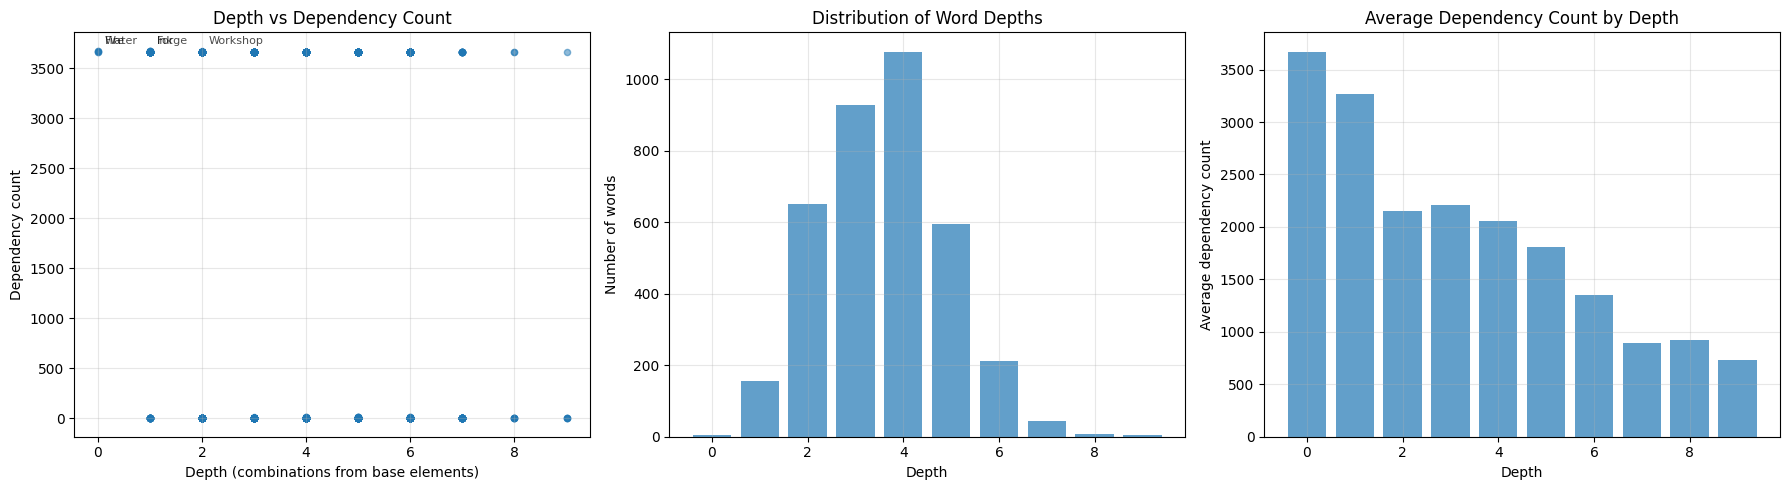


Depth Statistics:
  Min depth: 0
  Max depth: 9
  Mean depth: 3.59
  Median depth: 4.0

Dependency Count Statistics:
  Words with 0 dependencies (leaf nodes): 1527
  Words depended on by 100+ recipes: 3140
  Words depended on by 500+ recipes: 3140


In [ ]:
# Analyze relationship between dependency count and depth
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Filter out unreachable words (depth == -1)
valid_df = dependency_df[dependency_df['depth'] >= 0]

# Plot 1: Dependency count vs depth
ax1 = axes[0]
ax1.scatter(valid_df['depth'], valid_df['dependency_count'], alpha=0.5, s=20)
ax1.set_xlabel('Depth (combinations from base elements)')
ax1.set_ylabel('Dependency count')
ax1.set_title('Depth vs Dependency Count')
ax1.grid(True, alpha=0.3)

# Label some interesting points
for _, row in valid_df.nlargest(5, 'dependency_count').iterrows():
    ax1.annotate(row['word'], (row['depth'], row['dependency_count']), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

# Plot 2: Distribution of depths
ax2 = axes[1]
depth_counts = valid_df['depth'].value_counts().sort_index()
ax2.bar(depth_counts.index, depth_counts.values, alpha=0.7)
ax2.set_xlabel('Depth')
ax2.set_ylabel('Number of words')
ax2.set_title('Distribution of Word Depths')
ax2.grid(True, alpha=0.3)

# Plot 3: Average dependency count by depth
ax3 = axes[2]
avg_by_depth = valid_df.groupby('depth')['dependency_count'].mean()
ax3.bar(avg_by_depth.index, avg_by_depth.values, alpha=0.7)
ax3.set_xlabel('Depth')
ax3.set_ylabel('Average dependency count')
ax3.set_title('Average Dependency Count by Depth')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\nDepth Statistics:")
print(f"  Min depth: {valid_df['depth'].min()}")
print(f"  Max depth: {valid_df['depth'].max()}")
print(f"  Mean depth: {valid_df['depth'].mean():.2f}")
print(f"  Median depth: {valid_df['depth'].median()}")

print(f"\nDependency Count Statistics:")
print(f"  Words with 0 dependencies (leaf nodes): {len(dependency_df[dependency_df['dependency_count'] == 0])}")
print(f"  Words depended on by 100+ recipes: {len(dependency_df[dependency_df['dependency_count'] >= 100])}")
print(f"  Words depended on by 500+ recipes: {len(dependency_df[dependency_df['dependency_count'] >= 500])}")

## Sample Data

In [ ]:
# View recent combinations
query = """
SELECT * FROM combinations
ORDER BY id DESC
LIMIT 20
"""
pd.read_sql_query(query, conn)

,id,firstWord,secondWord,resultName,resultEmoji,username,timestamp,perUserRank,isDiscovery
0,9905,Dirt,Mist,Mud,🌿,boz,2026-01-10T15:30:31.027032,3,0
1,9904,Air,Mud,Mist,❄,boz,2026-01-10T15:30:21.086555,2,0
2,9903,Fog,Spring,Mist,❄,boz,2026-01-10T15:30:04.982005,5,0
3,9902,Warm breeze,Earth,Spring,💧,boz,2026-01-10T15:29:57.585875,4,0
4,9901,Geyser,Mist,Fog,❄,boz,2026-01-10T15:29:49.143170,4,0
5,9900,Mud,Warm breeze,Mist,❄,boz,2026-01-10T15:29:42.184121,4,0
6,9899,Warm breeze,Steam,Sauna,🧖,boz,2026-01-10T15:29:25.753218,4,1
7,9898,Smoke,Geyser,Steam,💧,boz,2026-01-10T15:29:24.301275,4,0
8,9897,Steam,Geothermal,Geyser,♨,boz,2026-01-10T15:29:22.685475,3,0
9,9896,Rickandmorty,Robot chicken,Adult Cartoon,📺,tim,2026-01-10T05:25:43.398373,224,1


## Custom Query
Write your own SQL query below:

In [ ]:
# Your custom query here
custom_query = """
SELECT * FROM combinations LIMIT 5
"""
pd.read_sql_query(custom_query, conn)

,id,firstWord,secondWord,resultName,resultEmoji,username,timestamp,perUserRank,isDiscovery
0,1,Fire,Water,Steam,💧,njj,2026-01-04T20:13:46.177126,1,1
1,2,Air,Air,Breeze,💨,njj,2026-01-04T20:13:49.231727,1,1
2,3,Water,Fire,Steam,💧,shm,2026-01-05T23:47:51.956799,1,0
3,4,Fire,Air,Flame,🔥,shm,2026-01-05T23:52:01.184969,1,1
4,5,Earth,Flame,Lava,🌋,shm,2026-01-05T23:52:25.560854,2,1


In [ ]:
# Close connection when done
# conn.close()
# print("Connection closed")